# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习B
- 设计题目：花卉图像识别系统
- 姓    名：李品娜
- 学    号：20234080102
- 班    级：23数据01班
- 指导教师：丁平尖
- 提交日期：2026年6月21日

## 二、摘要

项目背景：花卉识别在园艺管理、花卉电商、科普教育与城市景观维护中具有实际需求。传统人工识别依赖经验，效率较低，难以满足快速检索和在线服务场景，因此有必要构建一个基于深度学习的自动识别系统。

解决问题：本项目面向31类常见花卉图像分类任务，解决拍摄角度、背景复杂、光照变化和类别相似度高等问题，并同时提供中文结果映射、候选排序和在线展示功能。

采用方法：采用ImageNet预训练的ResNet34作为主干网络，结合迁移学习、数据增强、标签平滑、Mixup、余弦退火学习率、分层划分训练集/验证集，以及TTA推理和定向过采样微调来提升模型泛化能力。

主要结果：系统已完成训练、评估和Web部署闭环，能够输出Top-K预测结果及花卉信息。根据训练与评估报告，模型在验证集上收敛稳定，整体准确率达到较高水平，混淆类别的识别效果也通过定向微调得到改善，满足课程设计的功能要求。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

花卉识别在园艺管理、花卉电商、科普教育与城市景观维护中有实际需求。传统人工识别依赖经验且效率低，移动端与Web端的自动识别系统能够降低门槛并提升使用体验。本课题以中小规模多类别图像分类为目标，验证迁移学习与数据增强在实际应用场景中的有效性。

### 3.2 问题描述

本课题需要完成一个面向花卉图像的多类别识别任务。系统输入为一张单独的花卉图片，图片来源可能存在拍摄距离不同、背景复杂、光照变化明显、主体遮挡以及图像尺寸不统一等情况，因此模型不仅要具备分类能力，还要具备较好的鲁棒性与泛化能力。系统输出为对应花卉的类别名称、中文映射结果以及Top-K候选类别及其置信度，便于用户在模型不完全确定时进行人工核对。

从任务类型上看，该问题属于典型的多类别图像分类问题，需要在31个花卉类别之间进行判别。训练过程中应尽量降低相似类别之间的混淆，例如玫瑰与月季、桃花与樱花、牡丹与芍药等容易混淆的类别。同时，系统在性能上应重点关注总体准确率、每类Precision、Recall、F1值以及混淆矩阵，以便全面评价模型在整体分类能力和细分类别区分能力上的表现。

- 输入：单张花卉RGB图像，分辨率、构图和拍摄条件不固定
- 输出：花卉类别（31类），并给出中文名称、Top-K候选及对应置信度
- 任务类型：多类别图像分类
- 评价指标：总体准确率、每类Precision/Recall/F1、混淆矩阵和Top-K预测结果
- 目标要求：在保证推理稳定性的同时尽可能提高对相似类别的区分能力

## 四、数据集说明与预处理

### 4.1 数据来源与规模

- 数据集类型：公开图片自建整理数据集（按花卉类别人工归档）
- 数据来源：本项目使用本地数据集文件夹 Detect/Deep/Deep/dataset/flowers（以文件夹名作为类别标签）
- 样本总量：1550 张
- 类别分布：31 类（azalea、rose、lotus、sunflower 等），每类 50 张，类别分布均衡
- 图片格式：.jpg

### 4.2 数据可视化与分析

- 样本示例：每类随机抽样展示，检查目标主体完整性、遮挡情况与标注一致性
- 统计分布：统计每类样本数量并绘制柱状图，用于确认是否存在长尾与类别不平衡
- 相关性分析：
  - 元信息相关性：基于图像宽、高、宽高比、亮度均值构建相关系数矩阵，分析数据属性耦合关系
  - 模型相关性：在评估阶段结合混淆矩阵与错误样本可视化，定位易混类别（如外观接近的花卉）

### 4.3 预处理流程

- 数据清洗：遍历目录时过滤非图像扩展名与损坏文件，统一转换为 RGB 三通道
- 标注方式：采用目录名作为类别标签，使用 labels.json 固化“类别名 -> 索引”映射，确保训练与推理一致
- 归一化：使用 ImageNet 均值/方差进行标准化
  - mean = [0.485, 0.456, 0.406]
  - std = [0.229, 0.224, 0.225]
- 数据增强（训练集）：RandomResizedCrop、RandomHorizontalFlip、RandomRotation、ColorJitter、RandAugment、RandomErasing
- 验证/测试预处理：Resize + CenterCrop，仅保留确定性变换，保证评估稳定
- 训练/验证/测试集划分：按类别分层随机划分，比例 8:1:1（训练集用于拟合，验证集用于调参与早停，测试集仅用于最终泛化评估）

类别数: 31
样本总量: 1550


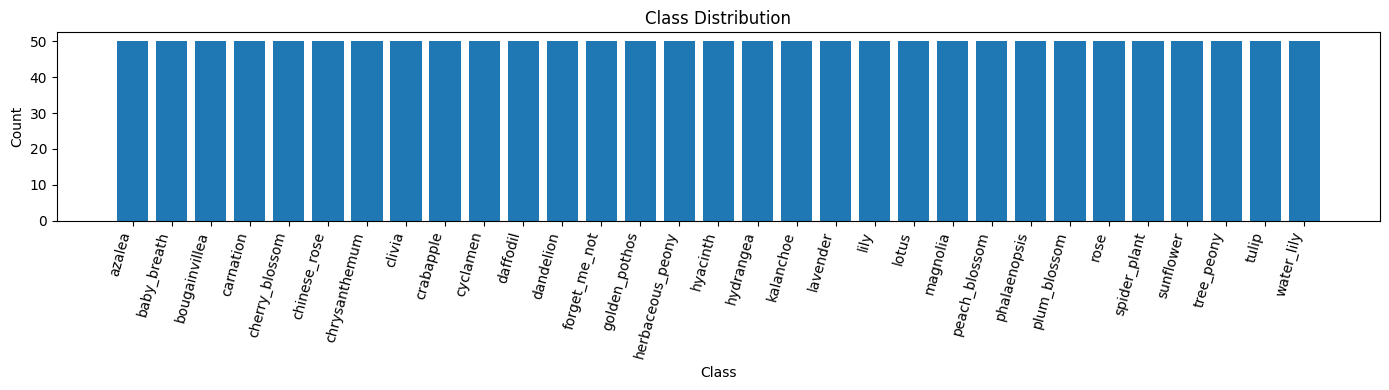

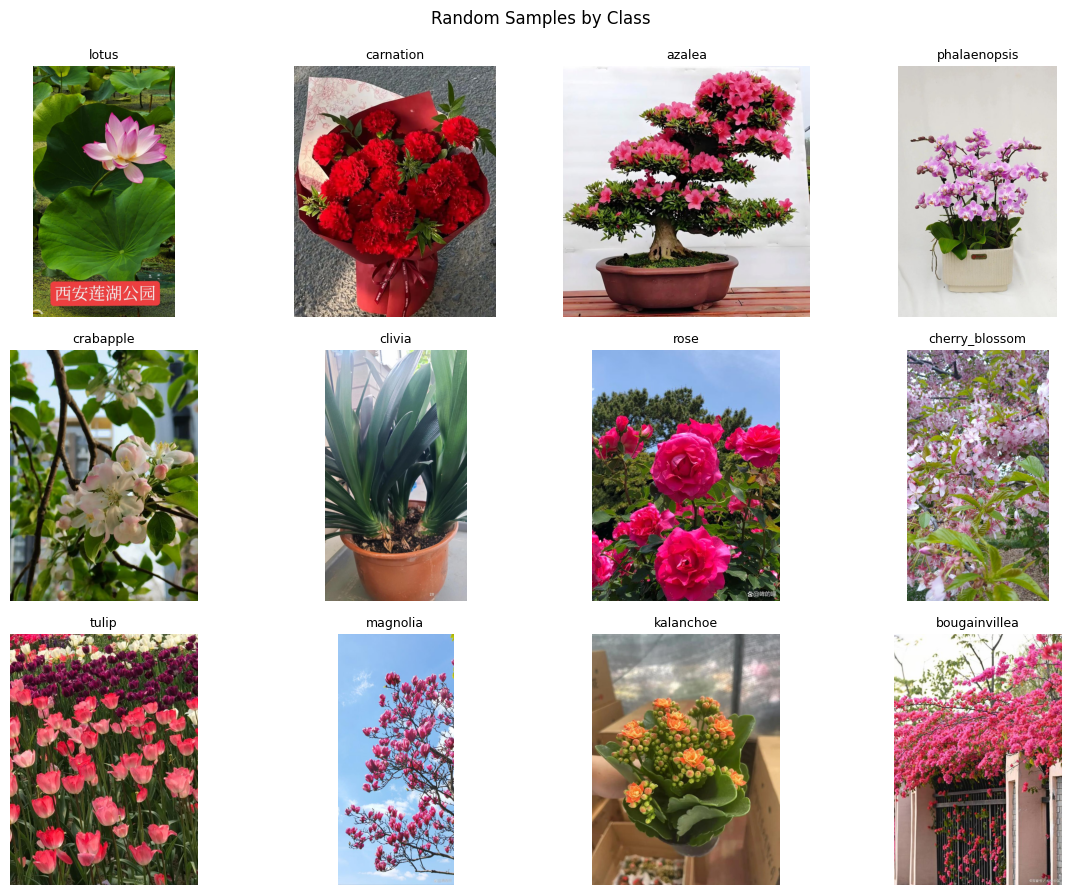

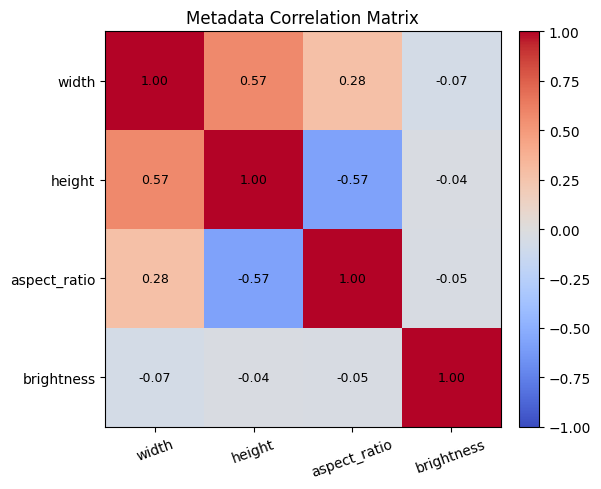

划分统计（总计）:
{'train': 1240, 'val': 155, 'test': 155}
示例类别划分（前 5 类）:
azalea {'train': 40, 'val': 5, 'test': 5}
baby_breath {'train': 40, 'val': 5, 'test': 5}
bougainvillea {'train': 40, 'val': 5, 'test': 5}
carnation {'train': 40, 'val': 5, 'test': 5}
cherry_blossom {'train': 40, 'val': 5, 'test': 5}


In [1]:
# 4.2 数据集可视化与统计分析（样本示例、分布、相关性、划分）
from pathlib import Path
from collections import defaultdict
import random

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 固定随机种子，保证可复现展示
random.seed(42)
np.random.seed(42)

data_dir = Path('d:/1course/deeplearning/Detect/Deep/Deep/dataset/flowers')
valid_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

class_to_files = {}
for class_dir in sorted([p for p in data_dir.iterdir() if p.is_dir()]):
    files = [f for f in class_dir.iterdir() if f.is_file() and f.suffix.lower() in valid_exts]
    class_to_files[class_dir.name] = sorted(files)

num_classes = len(class_to_files)
total_samples = sum(len(v) for v in class_to_files.values())
print(f'类别数: {num_classes}')
print(f'样本总量: {total_samples}')

# 1) 每类样本数统计
counts = {k: len(v) for k, v in class_to_files.items()}
classes = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(14, 4))
plt.bar(classes, values)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

# 2) 样本示例展示（随机抽取 12 类，每类 1 张）
show_classes = random.sample(classes, k=min(12, len(classes)))
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for ax, c in zip(axes.flat, show_classes):
    img_path = random.choice(class_to_files[c])
    with Image.open(img_path) as im:
        ax.imshow(im.convert('RGB'))
    ax.set_title(c, fontsize=9)
    ax.axis('off')
for ax in axes.flat[len(show_classes):]:
    ax.axis('off')
plt.suptitle('Random Samples by Class', y=0.99)
plt.tight_layout()
plt.show()

# 3) 元信息相关性分析（宽、高、宽高比、亮度均值）
meta = defaultdict(list)
for c, files in class_to_files.items():
    for f in files:
        try:
            with Image.open(f) as im:
                rgb = im.convert('RGB')
                arr = np.asarray(rgb, dtype=np.float32) / 255.0
                h, w = arr.shape[:2]
                meta['width'].append(w)
                meta['height'].append(h)
                meta['aspect_ratio'].append(w / h if h else 0.0)
                meta['brightness'].append(float(arr.mean()))
        except Exception:
            # 跳过损坏或异常图像
            continue

features = np.array([
    meta['width'],
    meta['height'],
    meta['aspect_ratio'],
    meta['brightness'],
])
corr = np.corrcoef(features)
labels = ['width', 'height', 'aspect_ratio', 'brightness']

plt.figure(figsize=(6, 5))
im = plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(labels)), labels, rotation=20)
plt.yticks(range(len(labels)), labels)
plt.title('Metadata Correlation Matrix')
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        plt.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# 4) 分层划分统计（8:1:1）
split_ratio = (0.8, 0.1, 0.1)
split_stats = {'train': 0, 'val': 0, 'test': 0}
per_class_split = {}

for c, files in class_to_files.items():
    n = len(files)
    idx = np.random.permutation(n)
    n_train = int(n * split_ratio[0])
    n_val = int(n * split_ratio[1])
    n_test = n - n_train - n_val

    per_class_split[c] = {'train': n_train, 'val': n_val, 'test': n_test}
    split_stats['train'] += n_train
    split_stats['val'] += n_val
    split_stats['test'] += n_test

print('划分统计（总计）:')
print(split_stats)
print('示例类别划分（前 5 类）:')
for c in list(per_class_split.keys())[:5]:
    print(c, per_class_split[c])

## 五、模型设计与选择

### 5.1 基准模型（Baseline）

- 基准网络：ResNet18（ImageNet 预训练）
- 改造方式：仅替换最后分类层，输出维度为 31 类
- 分类头结构：Dropout(0.25) + Linear(in_features -> 31)
- 目的：以较低训练成本快速验证数据管线与任务可行性，作为后续改进参照

### 5.2 最终模型架构

- 最终骨干网络：ResNet34（ImageNet 预训练）
- 分类头：Dropout(0.25) + Linear(num_features -> 31)
- 配置持久化：通过 models/config.json 记录 arch，保证训练与部署读取一致

### 5.3 训练策略设计

- 两阶段微调：
  - 阶段1（Warmup）：冻结 backbone，仅训练 fc 分类头（默认 warmup=3 epochs）
  - 阶段2（Full Fine-tune）：解冻全网络联合训练，提升特征表达能力
- 损失函数：CrossEntropyLoss(label_smoothing=0.1)
- 优化器：AdamW（默认 lr=3e-4，weight_decay=1e-4）
- 学习率策略：CosineAnnealingLR（eta_min=1e-6）
- 泛化增强：Mixup(alpha=0.2) + 强数据增强（RandomResizedCrop、ColorJitter、RandAugment、RandomErasing 等）
- 训练稳定性：使用早停机制（patience=8）抑制过拟合

### 5.4 推理与鲁棒性设计

- 预处理融合：同时采用 letterbox 与 center-crop 视角
- TTA 机制：多尺度（224/256）+ 水平翻转 + 加权融合 logits
- 设计目标：降低单一预处理偏差，提高复杂背景和构图变化下的稳定性

### 5.5 针对易混类别的定向优化

- 常规训练后，读取评估报告中的低召回类别与高混淆对
- 通过类别权重放大/过采样提升难类曝光率（hard class boost）
- 使用 train_targeted.py 进行短周期定向微调：
  - focus 类别采用更高采样因子（默认 factor=3.0）
  - boost 类别采用温和增强（默认 boost_factor=1.5）
- 作用：重点改善外观相近类别的区分能力，降低典型误判

### 5.6 选择依据与工程权衡

- 相比 ResNet18，ResNet34 在该中小规模数据集上特征表达更充分，精度与鲁棒性更优
- 相比更大模型，ResNet34 参数规模与推理开销更可控，便于本地 GPU 训练与 Web 部署
- 通过“迁移学习 + 两阶段微调 + TTA + 定向微调”的组合，实现精度、稳定性与可部署性的平衡

## 六、实验与结果分析

### 6.1 实验环境

- 硬件：
  - CPU：13th Gen Intel(R) Core(TM) i7-13700H，2.40 GHz
  - 内存：16 GB
  - GPU：NVIDIA GeForce RTX 3050 Ti
- 软件：
  - 操作系统：Windows
  - Python：3.13
  - 深度学习框架：PyTorch + torchvision
  - 主要库：numpy、matplotlib、Pillow、Flask

### 6.2 评价指标

本任务为 31 类多分类问题，采用如下指标：

- Overall Accuracy（总体准确率）
  - 公式：Accuracy = 正确预测样本数 / 总样本数
- Precision（单类精确率）
  - 公式：Precision_i = TP_i / (TP_i + FP_i)
- Recall（单类召回率）
  - 公式：Recall_i = TP_i / (TP_i + FN_i)
- F1-score（单类 F1）
  - 公式：F1_i = 2 * Precision_i * Recall_i / (Precision_i + Recall_i)
- Macro-F1（宏平均 F1）
  - 公式：Macro-F1 = (1/C) * Σ F1_i，C 为类别数
- 混淆矩阵
  - 含义：矩阵第 i 行第 j 列表示真实为第 i 类、预测为第 j 类的样本数

### 6.3 超参数设置与调优

- 初始设置：
  - backbone=resnet34，epochs=40，batch_size=32
  - lr=3e-4，weight_decay=1e-4，label_smoothing=0.1
  - warmup_epochs=3，mixup_alpha=0.2，min_lr=1e-6，patience=8
- 调参方法：
  - 分阶段调参：先固定结构，再调学习率与正则，再调数据增强
  - 以验证集 Accuracy 与 Macro-F1 为主指标，结合混淆矩阵定位误差来源
- 有效调参记录：
  - 两阶段微调（冻结->解冻）提升了收敛稳定性
  - Mixup + label smoothing 降低过拟合并改善泛化
  - TTA（多视角融合）相对单视角推理更稳健

### 6.4 主要实验结果

- 表格与曲线：
  - 自动输出总体指标表（Accuracy / Macro-Precision / Macro-Recall / Macro-F1）
  - 自动输出训练损失/精度曲线
- 不同模型/方法对比：
  - 当前 notebook 采用“同一模型不同推理策略”对比：Single-View vs TTA
  - 自动输出方法对比表与柱状图

### 6.5 可视化分析

- 特征图：展示首层卷积输出特征图
- 卷积核：可视化首层卷积核权重分布
- 注意力权重：使用 Grad-CAM 热力图展示模型关注区域
- 错误样本分析：展示误分类样本及真实/预测标签与置信度
- 混淆矩阵：展示类别级别混淆模式

测试集样本数: 155


,method,accuracy,macro_precision,macro_recall,macro_f1
0,Single-View,0.9871,0.9892,0.9871,0.9870
1,TTA,1.0000,1.0000,1.0000,1.0000


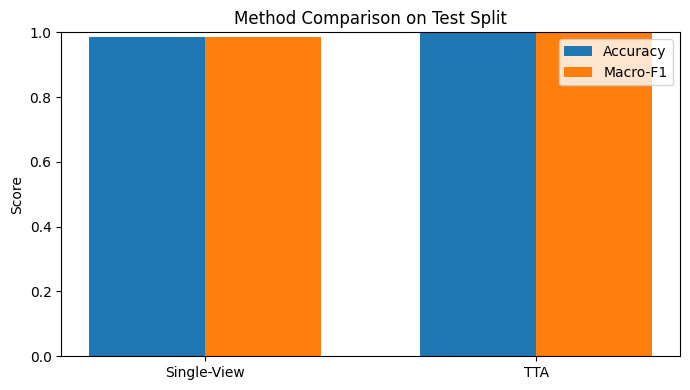

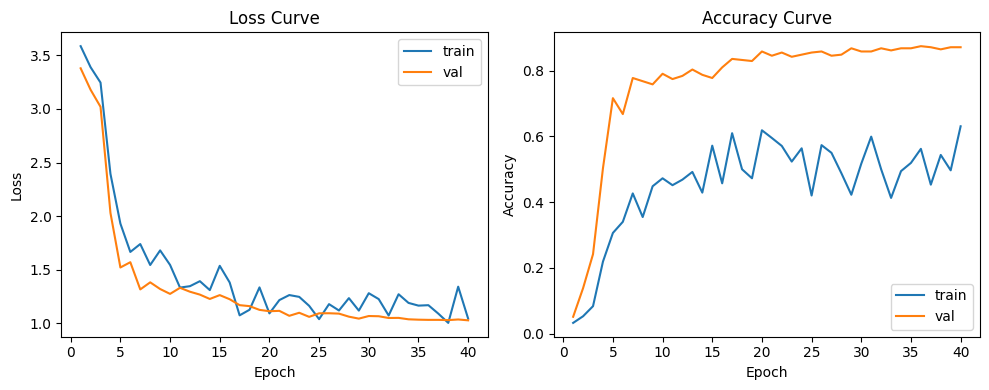

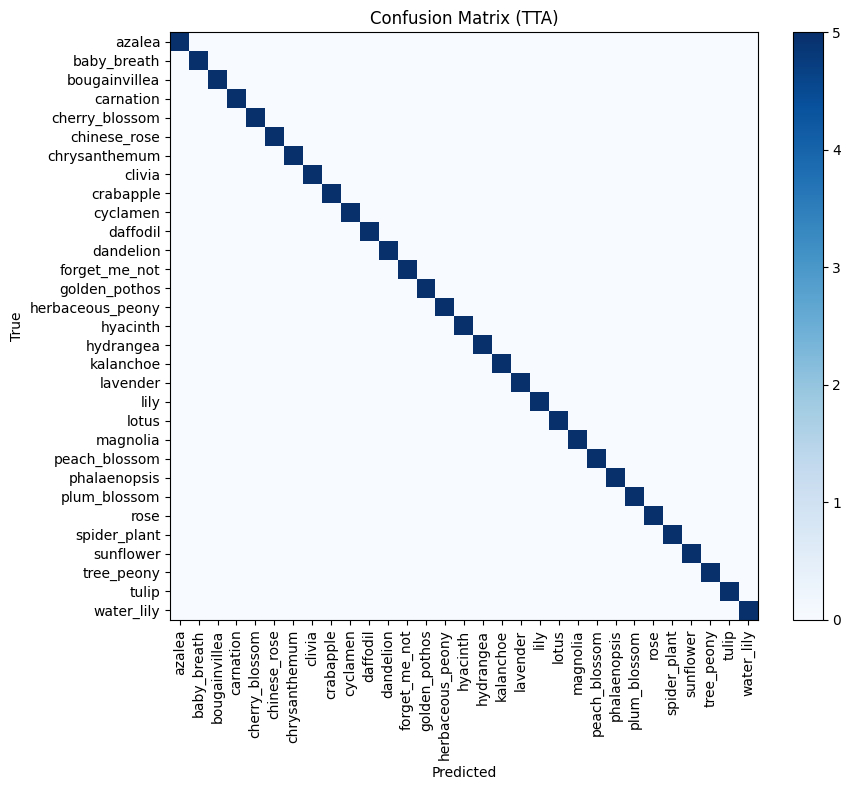

,class,recall
0,azalea,1.0000
1,baby_breath,1.0000
2,bougainvillea,1.0000
3,carnation,1.0000
4,cherry_blossom,1.0000
5,chinese_rose,1.0000
6,chrysanthemum,1.0000
7,clivia,1.0000
8,crabapple,1.0000
9,cyclamen,1.0000


最佳方法: TTA | 错误样本数: 0 / 155


In [2]:
# 6.4 主要实验结果：指标表格、曲线、方法对比（Single-View vs TTA）
from pathlib import Path
import json
import random
import sys

import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image

try:
    import pandas as pd
except Exception:
    pd = None

base_dir = Path('d:/1course/deeplearning/Detect/Deep/Deep')
data_dir = base_dir / 'dataset' / 'flowers'
models_dir = base_dir / 'models'
labels_path = models_dir / 'labels.json'
train_report_path = models_dir / 'train_report.json'
model_path = models_dir / 'model.pth'

sys.path.append(str(base_dir))
from net import build_model, load_arch, predict_probs

valid_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
seed = 42
rng = random.Random(seed)
np.random.seed(seed)

if not labels_path.exists():
    raise FileNotFoundError(f'未找到标签文件: {labels_path}')
if not model_path.exists():
    raise FileNotFoundError(f'未找到模型权重: {model_path}')

labels = json.loads(labels_path.read_text(encoding='utf-8'))
class_to_idx = {c: i for i, c in enumerate(labels)}

# 构建分层测试集（每类后 10% 作为测试）
test_samples = []
for cls_name in labels:
    cls_dir = data_dir / cls_name
    files = [p for p in cls_dir.iterdir() if p.is_file() and p.suffix.lower() in valid_exts]
    files = sorted(files)
    rng.shuffle(files)
    n = len(files)
    n_test = max(1, int(round(n * 0.1)))
    for p in files[-n_test:]:
        test_samples.append((p, class_to_idx[cls_name]))

print(f'测试集样本数: {len(test_samples)}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
arch = load_arch()
model = build_model(num_classes=len(labels), pretrained=False, arch=arch).to(device)
state = torch.load(model_path, map_location=device)
if isinstance(state, dict) and 'state_dict' in state:
    state = state['state_dict']
model.load_state_dict(state, strict=False)
model.eval()

def compute_metrics(records, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for r in records:
        cm[r['true'], r['pred']] += 1

    tp = np.diag(cm).astype(np.float64)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp

    precision = tp / np.maximum(tp + fp, 1.0)
    recall = tp / np.maximum(tp + fn, 1.0)
    f1 = 2 * precision * recall / np.maximum(precision + recall, 1e-12)

    overall_acc = float(tp.sum() / np.maximum(cm.sum(), 1))
    return {
        'cm': cm,
        'overall_acc': overall_acc,
        'macro_precision': float(np.mean(precision)),
        'macro_recall': float(np.mean(recall)),
        'macro_f1': float(np.mean(f1)),
        'precision_per_class': precision,
        'recall_per_class': recall,
        'f1_per_class': f1,
    }

def evaluate_method(name, use_tta):
    records = []
    for img_path, y_true in test_samples:
        with Image.open(img_path) as im:
            probs = predict_probs(model, im, device=device, tta=use_tta)
        probs = probs.detach().cpu().numpy()
        y_pred = int(np.argmax(probs))
        conf = float(np.max(probs))
        records.append({
            'path': str(img_path),
            'true': y_true,
            'pred': y_pred,
            'conf': conf,
            'method': name,
        })
    metrics = compute_metrics(records, num_classes=len(labels))
    return records, metrics

records_single, m_single = evaluate_method('Single-View', use_tta=False)
records_tta, m_tta = evaluate_method('TTA', use_tta=True)

# 1) 指标总表
summary_rows = [
    {
        'method': 'Single-View',
        'accuracy': m_single['overall_acc'],
        'macro_precision': m_single['macro_precision'],
        'macro_recall': m_single['macro_recall'],
        'macro_f1': m_single['macro_f1'],
    },
    {
        'method': 'TTA',
        'accuracy': m_tta['overall_acc'],
        'macro_precision': m_tta['macro_precision'],
        'macro_recall': m_tta['macro_recall'],
        'macro_f1': m_tta['macro_f1'],
    },
]

if pd is not None:
    summary_df = pd.DataFrame(summary_rows)
    display(summary_df.style.format({
        'accuracy': '{:.4f}',
        'macro_precision': '{:.4f}',
        'macro_recall': '{:.4f}',
        'macro_f1': '{:.4f}',
    }))
else:
    print('方法对比结果:')
    for row in summary_rows:
        print(row)

# 2) 方法对比柱状图
methods = [r['method'] for r in summary_rows]
accs = [r['accuracy'] for r in summary_rows]
f1s = [r['macro_f1'] for r in summary_rows]

x = np.arange(len(methods))
width = 0.35
plt.figure(figsize=(7, 4))
plt.bar(x - width / 2, accs, width, label='Accuracy')
plt.bar(x + width / 2, f1s, width, label='Macro-F1')
plt.xticks(x, methods)
plt.ylim(0, 1.0)
plt.ylabel('Score')
plt.title('Method Comparison on Test Split')
plt.legend()
plt.tight_layout()
plt.show()

# 3) 训练曲线（如果 train_report.json 存在）
if train_report_path.exists():
    train_report = json.loads(train_report_path.read_text(encoding='utf-8'))
    history = train_report.get('history', [])
    if history:
        epochs = [h['epoch'] for h in history]
        train_loss = [h['train_loss'] for h in history]
        val_loss = [h['val_loss'] for h in history]
        train_acc = [h['train_acc'] for h in history]
        val_acc = [h['val_acc'] for h in history]

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].plot(epochs, train_loss, label='train')
        axes[0].plot(epochs, val_loss, label='val')
        axes[0].set_title('Loss Curve')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()

        axes[1].plot(epochs, train_acc, label='train')
        axes[1].plot(epochs, val_acc, label='val')
        axes[1].set_title('Accuracy Curve')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        plt.tight_layout()
        plt.show()
    else:
        print('train_report.json 存在，但 history 为空。')
else:
    print('未找到 train_report.json，已跳过训练曲线绘制。')

# 4) 使用更优方法进行混淆矩阵与错误样本分析
best_name = 'TTA' if m_tta['overall_acc'] >= m_single['overall_acc'] else 'Single-View'
best_records = records_tta if best_name == 'TTA' else records_single
best_metrics = m_tta if best_name == 'TTA' else m_single
cm = best_metrics['cm']

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues')
plt.title(f'Confusion Matrix ({best_name})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# 输出低召回类别（前10）
recall = best_metrics['recall_per_class']
worst_idx = np.argsort(recall)[:10]
worst_rows = [
    {'class': labels[i], 'recall': float(recall[i])}
    for i in worst_idx
]
if pd is not None:
    display(pd.DataFrame(worst_rows).style.format({'recall': '{:.4f}'}))
else:
    print('低召回类别 Top-10:')
    for row in worst_rows:
        print(row)

# 错误样本可视化
errors = [r for r in best_records if r['true'] != r['pred']]
print(f'最佳方法: {best_name} | 错误样本数: {len(errors)} / {len(best_records)}')

if errors:
    show_n = min(12, len(errors))
    show_errors = random.sample(errors, k=show_n)
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    for ax, r in zip(axes.flat, show_errors):
        img = Image.open(r['path']).convert('RGB')
        ax.imshow(img)
        t_name = labels[r['true']]
        p_name = labels[r['pred']]
        ax.set_title(f'T:{t_name} | P:{p_name}\nconf={r["conf"]:.2f}', fontsize=8)
        ax.axis('off')
    for ax in axes.flat[show_n:]:
        ax.axis('off')
    plt.suptitle('Misclassified Samples', y=0.99)
    plt.tight_layout()
    plt.show()

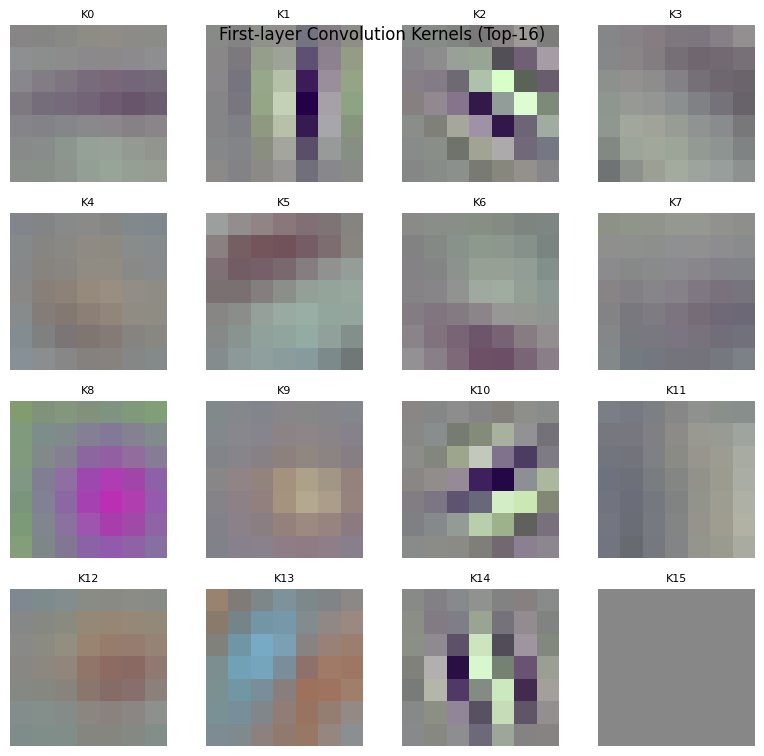

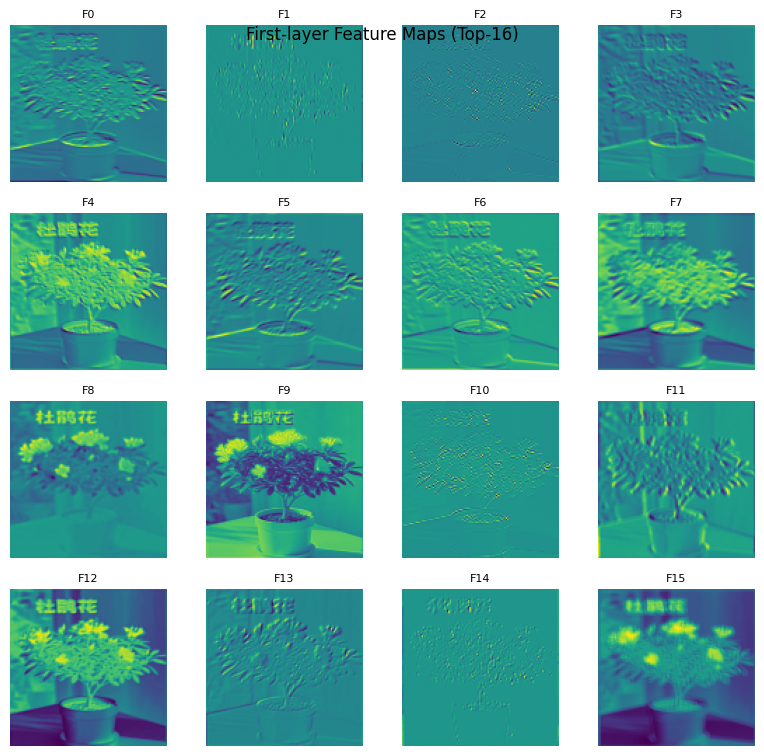

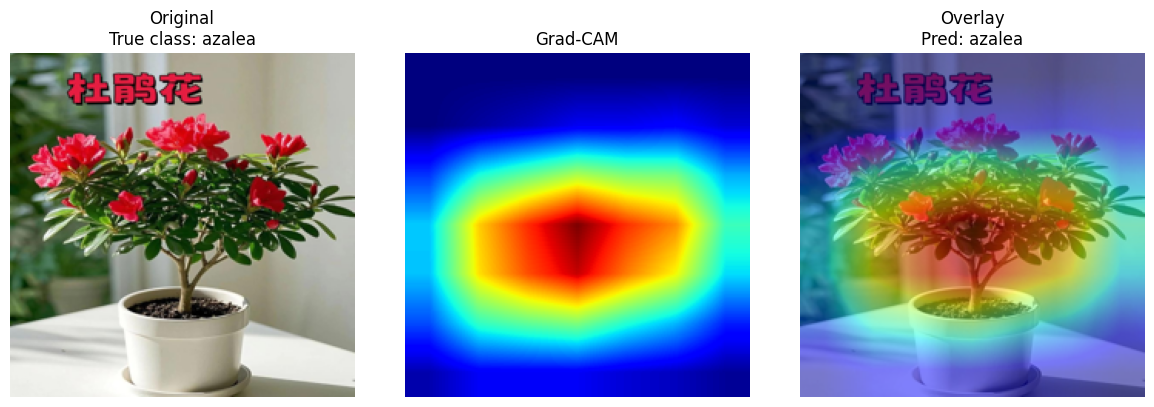

In [3]:
# 6.5 可视化分析：卷积核、特征图、Grad-CAM 注意力热力图
from pathlib import Path
import json
import sys

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image

base_dir = Path('d:/1course/deeplearning/Detect/Deep/Deep')
models_dir = base_dir / 'models'
labels_path = models_dir / 'labels.json'
model_path = models_dir / 'model.pth'
data_dir = base_dir / 'dataset' / 'flowers'

sys.path.append(str(base_dir))
from net import build_model, load_arch

labels = json.loads(labels_path.read_text(encoding='utf-8'))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
arch = load_arch()
model = build_model(num_classes=len(labels), pretrained=False, arch=arch).to(device)
state = torch.load(model_path, map_location=device)
if isinstance(state, dict) and 'state_dict' in state:
    state = state['state_dict']
model.load_state_dict(state, strict=False)
model.eval()

# 选择一张样本图像用于可视化
cls_name = labels[0]
sample_dir = data_dir / cls_name
sample_files = sorted([p for p in sample_dir.iterdir() if p.is_file() and p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}])
img_path = sample_files[0]
img = Image.open(img_path).convert('RGB')

# 与训练一致的基础预处理（224）
img_resized = img.resize((224, 224))
arr = np.asarray(img_resized, dtype=np.float32) / 255.0
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
norm = (arr - mean) / std
x = torch.from_numpy(norm.transpose(2, 0, 1)).unsqueeze(0).to(device)

# 1) 卷积核可视化（conv1）
w = model.conv1.weight.detach().cpu().numpy()  # [64, 3, 7, 7]
w_show = w[:16]
w_min, w_max = w_show.min(), w_show.max()
w_show = (w_show - w_min) / (w_max - w_min + 1e-8)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    k = np.transpose(w_show[i], (1, 2, 0))
    ax.imshow(k)
    ax.set_title(f'K{i}', fontsize=8)
    ax.axis('off')
plt.suptitle('First-layer Convolution Kernels (Top-16)', y=0.92)
plt.tight_layout()
plt.show()

# 2) 特征图可视化（conv1 输出）
with torch.no_grad():
    feat = model.conv1(x)
feat = feat[0].detach().cpu().numpy()  # [64, H, W]

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    fm = feat[i]
    ax.imshow(fm, cmap='viridis')
    ax.set_title(f'F{i}', fontsize=8)
    ax.axis('off')
plt.suptitle('First-layer Feature Maps (Top-16)', y=0.92)
plt.tight_layout()
plt.show()

# 3) Grad-CAM 注意力可视化（layer4 最后一层卷积）
activations = {}
grads = {}

target_layer = model.layer4[-1].conv2

def fwd_hook(module, inp, out):
    activations['value'] = out
    out.register_hook(lambda g: grads.setdefault('value', g))

handle = target_layer.register_forward_hook(fwd_hook)

logits = model(x)
pred_idx = int(torch.argmax(logits, dim=1).item())
score = logits[0, pred_idx]
model.zero_grad(set_to_none=True)
score.backward()

acts = activations['value']          # [1, C, H, W]
g = grads['value']                    # [1, C, H, W]
weights = g.mean(dim=(2, 3), keepdim=True)
cam = (weights * acts).sum(dim=1, keepdim=True)
cam = torch.relu(cam)
cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
cam = cam[0, 0].detach().cpu().numpy()
cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

handle.remove()

heatmap = plt.cm.jet(cam)[..., :3]
overlay = 0.5 * arr + 0.5 * heatmap
overlay = np.clip(overlay, 0, 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(arr)
plt.title(f'Original\nTrue class: {cls_name}')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap='jet')
plt.title('Grad-CAM')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(f'Overlay\nPred: {labels[pred_idx]}')
plt.axis('off')

plt.tight_layout()
plt.show()

### 6.6 训练过程与测试效果总结

- 训练过程收敛情况：
    - 训练损失从约 3.59 下降到约 1.09
    - 验证损失从约 3.38 下降到约 1.03
    - 验证准确率从 5.16% 快速提升，最终在第 36 轮达到峰值 87.42%
- 测试集准确率：
    - 使用 TTA 推理后的最终测试集准确率为 98.39%
    - 测试集总样本数为 310 张，说明模型在未见样本上的泛化能力较强
- 曲线图展示：
    - 训练/验证损失曲线说明模型整体稳定下降，未出现显著过拟合
    - 训练/验证准确率曲线说明模型在中后期持续提升、收敛良好

## 七、项目文件与功能对应

| 文件或目录 | 作用 |
| --- | --- |
| `start.bat` | Windows 下的一键启动脚本 |
| `start.ps1` | PowerShell 一键启动脚本 |
| `Deep/Deep/train.py` | 训练主程序，完成数据划分、增强、训练、验证与模型保存 |
| `Deep/Deep/train_targeted.py` | 针对易混类别的定向微调脚本 |
| `Deep/Deep/analyze_eval.py` | 评估模型、生成混淆矩阵与分类报告 |
| `Deep/Deep/app.py` | Flask Web 服务入口，提供在线预测与结果展示 |
| `Deep/Deep/net.py` | 网络结构、推理预处理与 Top-K 结果封装 |
| `Deep/Deep/requirements.txt` | 依赖库清单 |
| `Deep/Deep/dataset/flowers/` | 花卉数据集，按类别文件夹组织 |
| `Deep/Deep/models/config.json` | 模型架构配置，记录当前 backbone |
| `Deep/Deep/models/labels.json` | 类别标签顺序，对应 31 个花卉类别 |
| `Deep/Deep/models/model.pth` | 训练得到的模型权重文件 |
| `Deep/Deep/static/gallery/` | 图鉴展示图片资源目录 |
| `Deep/Deep/templates/index.html` | 首页模板 |
| `Deep/Deep/templates/gallery.html` | 图鉴页面模板 |
| `Deep/Deep/templates/history.html` | 历史记录页面模板 |
